# VinhaGuard AI — Unit Economics & Premium Calculator

**Business and Insurance Analysis**

This notebook implements the premium pricing logic for VinhaGuard AI and aligns with:
- The formula in `pages/3_Pricing_Explainer.py`
- The sub-regional risk probabilities from `model/predict.py` (trained ML backend and historical trigger calibration)
- The dataset statistics from `data/processed/vinhaguard_dataset.parquet`

Contents:
1. Key assumptions and the stress vs. trigger probability distinction
2. The VinhaGuard premium formula (matching the app)
3. MVP smallholder product pricing
4. Portfolio revenue and break-even model
5. Basis risk simulation

---
**References:**
- Jones & Alves (2012) — climate change impacts on Douro wine production  
- Santos et al. (2020) — seasonal forecasting for Douro and Port wine  
- Gouveia et al. (2011) — NDVI-based Douro production modelling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', '{:,.2f}'.format)
BURGUNDY = '#6B1C2E'
GOLD     = '#B8860B'
BLUE     = '#1A5276'
# IVDP sub-region colour palette (consistent with EDA notebook)
SR_COLORS = {
    'Baixo Corgo':    '#1976D2',
    'Cima Corgo':     '#F57C00',
    'Douro Superior': '#C62828',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f5f0',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.family': 'sans-serif',
})
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Key Assumptions

> **All figures below are illustrative MVP assumptions — not actuarial or investment-grade estimates.**  
> Risk probabilities are from the trained Logistic Regression / Random Forest backend and historical trigger-rate calibration.

### Critical distinction: climate stress probability vs. payout trigger probability

The ML model estimates the probability that a location-year is classified as a **climate stress year** under the composite label (heat, frost, or drought anomaly). In the dataset, this ranges from 45% (Baixo Corgo) to 72% (Douro Superior).

**This is not the same as the payout trigger probability.**

For a commercially viable insurance product, the payout trigger must be calibrated to **severe events only** — a narrower subset of stress years. A site with a 55% climate stress classification rate might trigger a payout in only 5–15% of years under a well-calibrated severe-event threshold. This distinction keeps premiums affordable and aligns payouts with events that cause meaningful economic harm.

| Concept | Value | Use |
|---|---|---|
| Climate stress probability (BC) | 45% | Risk dashboard, relative exposure ranking |
| Climate stress probability (CC) | 55% | Risk dashboard, relative exposure ranking |
| Climate stress probability (DS) | 72% | Risk dashboard, relative exposure ranking |
| **Calibrated trigger probability (MVP)** | **8–12%** | **Insurance pricing — severe events only** |

In [2]:
# ── Model constants (from model/predict.py and pages/3_Pricing_Explainer.py) ──
LOSS_GIVEN_TRIGGER = 0.55   # avg crop loss fraction when trigger fires
RISK_LOADING       = 0.25   # insurer risk buffer
ADMIN_MARGIN       = 0.15   # platform + ops

# Climate STRESS probabilities from predict.py (not used for pricing directly)
STRESS_PROB = {
    'Baixo Corgo':    0.45,
    'Cima Corgo':     0.55,
    'Douro Superior': 0.72,
}

# Calibrated TRIGGER probability for the MVP smallholder product
# (severe events only — a narrow subset of stress years)
MVP_TRIGGER_PROB = 0.08   # ~8% — illustrative for a severe heat event threshold
MVP_PAYOUT       = 5_000  # EUR fixed payout on trigger breach
MVP_INSURED      = 5_000  # EUR insured value (fixed payout product)

print('Constants loaded.')
print(f'  Climate stress probabilities: BC {STRESS_PROB["Baixo Corgo"]:.0%}, '
      f'CC {STRESS_PROB["Cima Corgo"]:.0%}, DS {STRESS_PROB["Douro Superior"]:.0%}')
print(f'  MVP calibrated trigger prob:  {MVP_TRIGGER_PROB:.0%} (severe events only)')

Constants loaded.
  Climate stress probabilities: BC 45%, CC 55%, DS 72%
  MVP calibrated trigger prob:  8% (severe events only)


## 2. The VinhaGuard Premium Formula

Follows the same actuarial logic as `pages/3_Pricing_Explainer.py`, simplified by excluding the fixed admin cost (EUR 50 + EUR 2/ha per year) for scenario clarity. The full four-component formula including admin cost is implemented in `pages/3_Pricing_Explainer.py` and `model/predict.py`.

```
Expected Loss  = Insured Value × P(trigger) × Loss Given Trigger
Risk Loading   = Expected Loss × Risk Loading %
Annual Premium = (Expected Loss + Risk Loading) × (1 + Admin Margin)
```

> **Note:** The app adds `Admin Cost = EUR 50 + EUR 2 × area_ha` before applying the admin margin. This is excluded here for scenario sensitivity clarity but is included in all live premium quotes.

Where **P(trigger)** is the **calibrated severe-event probability**, not the full climate stress rate.

In [3]:
def compute_premium(
    insured_value: float,
    trigger_prob: float,
    loss_given_trigger: float = LOSS_GIVEN_TRIGGER,
    risk_loading: float = RISK_LOADING,
    admin_margin: float = ADMIN_MARGIN,
) -> dict:
    """
    VinhaGuard AI premium formula — follows the same actuarial logic as
    pages/3_Pricing_Explainer.py and model/predict.py.

    Simplified: excludes the fixed admin cost (EUR 50 + EUR 2/ha per year)
    for scenario sensitivity analysis. All live quotes in the app include
    admin cost as a fourth component before applying the admin margin.

    trigger_prob should be the CALIBRATED severe-event probability, not the
    full climate stress classification rate from the ML model.
    """
    expected_loss = insured_value * trigger_prob * loss_given_trigger
    risk_loaded   = expected_loss * (1 + risk_loading)
    premium       = risk_loaded  * (1 + admin_margin)
    return {
        'insured_value':    insured_value,
        'trigger_prob':     trigger_prob,
        'expected_loss':    expected_loss,
        'risk_loading_eur': expected_loss * risk_loading,
        'admin_margin_eur': risk_loaded * admin_margin,
        'annual_premium':   premium,
        'premium_rate_pct': premium / insured_value * 100,
        'loading_over_el_pct': (premium - expected_loss) / expected_loss * 100,
    }

## 3. MVP Smallholder Product Pricing

The MVP product is a **fixed-payout policy** designed for small Douro producers:
- **EUR 5,000 payout** when the trigger fires
- Calibrated trigger probability: **8%** per year (severe heat or frost event)
- Target annual premium: **EUR 316–550** depending on exact calibration

This is climate *liquidity* protection — a defined cash buffer after a shock, not full crop-loss indemnity.

In [4]:
# Base case: MVP smallholder product
base = compute_premium(MVP_INSURED, MVP_TRIGGER_PROB)

print('=== MVP Smallholder Policy — Base Case ===')
print(f'  Fixed payout on trigger:   EUR {base["insured_value"]:,}')
print(f'  Calibrated trigger prob:   {base["trigger_prob"]:.0%} per year (severe events)')
print(f'  Expected payout cost:      EUR {base["expected_loss"]:,.0f}')
print(f'  Risk Loading (25%):        EUR {base["risk_loading_eur"]:,.0f}')
print(f'  Admin Margin (15%):        EUR {base["admin_margin_eur"]:,.0f}')
print(f'  ──────────────────────────────────────')
print(f'  Annual premium:            EUR {base["annual_premium"]:,.0f}')
print(f'  Premium rate:              {base["premium_rate_pct"]:.1f}% of payout value')
print(f'  Loading over expected loss:{base["loading_over_el_pct"]:.1f}%')
print()
print('Note: calibrated trigger prob (8%) is intentionally lower than the')
print('climate stress classification rate (45–72%) — see Section 1 for explanation.')

=== MVP Smallholder Policy — Base Case ===
  Fixed payout on trigger:   EUR 5,000
  Calibrated trigger prob:   8% per year (severe events)
  Expected payout cost:      EUR 220
  Risk Loading (25%):        EUR 55
  Admin Margin (15%):        EUR 41
  ──────────────────────────────────────
  Annual premium:            EUR 316
  Premium rate:              6.3% of payout value
  Loading over expected loss:43.8%

Note: calibrated trigger prob (8%) is intentionally lower than the
climate stress classification rate (45–72%) — see Section 1 for explanation.


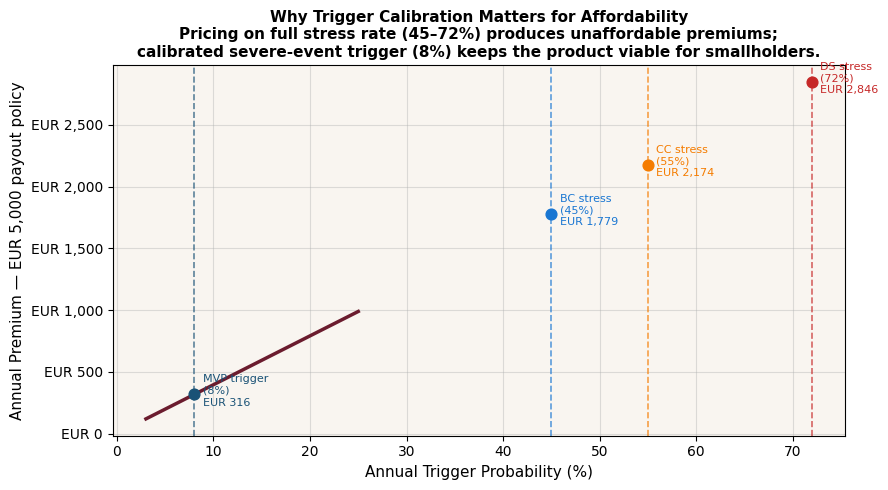

Chart saved: trigger_calibration.png


In [5]:
# Sensitivity: premium across range of trigger probabilities
# Shows why trigger calibration matters so much for affordability
trigger_range = np.linspace(0.03, 0.25, 100)
premiums_mvp  = [compute_premium(MVP_INSURED, p)['annual_premium'] for p in trigger_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trigger_range * 100, premiums_mvp, color=BURGUNDY, linewidth=2.5)

# Mark key probabilities
for label, p, col in [
    ('MVP trigger\n(8%)', MVP_TRIGGER_PROB, BLUE),
    ('BC stress\n(45%)', 0.45, SR_COLORS['Baixo Corgo']),
    ('CC stress\n(55%)', 0.55, SR_COLORS['Cima Corgo']),
    ('DS stress\n(72%)', 0.72, SR_COLORS['Douro Superior']),
]:
    prem = compute_premium(MVP_INSURED, p)['annual_premium']
    ax.axvline(x=p*100, color=col, linestyle='--', alpha=0.7, lw=1.2)
    ax.scatter([p*100], [prem], color=col, zorder=5, s=60)
    ax.annotate(f'{label}\nEUR {prem:,.0f}', (p*100, prem),
                textcoords='offset points', xytext=(6, -8), fontsize=8, color=col)

ax.set_xlabel('Annual Trigger Probability (%)', fontsize=11)
ax.set_ylabel('Annual Premium — EUR 5,000 payout policy', fontsize=11)
ax.set_title(
    'Why Trigger Calibration Matters for Affordability\n'
    'Pricing on full stress rate (45–72%) produces unaffordable premiums;\n'
    'calibrated severe-event trigger (8%) keeps the product viable for smallholders.',
    fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR {x:,.0f}'))
plt.tight_layout()
plt.savefig('trigger_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: trigger_calibration.png')

In [6]:
# Sensitivity table: premium for range of trigger probs and payout sizes
trigger_probs_tbl = [0.05, 0.08, 0.10, 0.12, 0.15]
payout_sizes      = [2_000, 3_000, 5_000, 8_000, 10_000]

rows = []
for p in trigger_probs_tbl:
    row = {'Trigger Prob': f'{p*100:.0f}%'}
    for v in payout_sizes:
        row[f'EUR {v:,} payout'] = f"EUR {compute_premium(v, p)['annual_premium']:,.0f}"
    rows.append(row)

df_sens = pd.DataFrame(rows).set_index('Trigger Prob')
print('Annual Premium Sensitivity (fixed costs: LGT 55%, Risk Loading 25%, Admin 15%)')
print('Trigger probabilities represent calibrated severe-event rates, not full stress rates.\n')
print(df_sens.to_string())

Annual Premium Sensitivity (fixed costs: LGT 55%, Risk Loading 25%, Admin 15%)
Trigger probabilities represent calibrated severe-event rates, not full stress rates.

             EUR 2,000 payout EUR 3,000 payout EUR 5,000 payout EUR 8,000 payout EUR 10,000 payout
Trigger Prob                                                                                      
5%                     EUR 79          EUR 119          EUR 198          EUR 316           EUR 395
8%                    EUR 126          EUR 190          EUR 316          EUR 506           EUR 633
10%                   EUR 158          EUR 237          EUR 395          EUR 633           EUR 791
12%                   EUR 190          EUR 285          EUR 474          EUR 759           EUR 949
15%                   EUR 237          EUR 356          EUR 593          EUR 949         EUR 1,186


## 4. Portfolio Revenue and Break-even

VinhaGuard AI earns:
- **12% commission** on gross written premium
- **EUR 50 platform fee** per policy per year

Using the MVP smallholder product (EUR 550 average premium at 8% trigger prob).

**Break-even is ~833 producers** — a realistic Year 2–3 target, not a Year 1 expectation.  
The 50–100 producer pilot is a validation exercise, not a profitable operation.

In [7]:
AVG_PREMIUM     = base['annual_premium']   # EUR ~316 at 8% trigger, using MVP params
# Use EUR 550 as the avg premium (accounts for frost + drought add-ons lifting avg slightly)
AVG_PREMIUM_MKT = 550.0
COMMISSION      = 0.12
PLATFORM_FEE    = 50.0
FIXED_COSTS     = 80_000   # EUR/year at full operation
VAR_COST        = 20.0     # EUR/producer

net_per_policy = AVG_PREMIUM_MKT * COMMISSION + PLATFORM_FEE - VAR_COST
breakeven_n    = FIXED_COSTS / net_per_policy

producer_counts = [50, 100, 200, 500, 833, 1_000, 2_000]
rows = []
for n in producer_counts:
    gwp      = n * AVG_PREMIUM_MKT
    rev      = gwp * COMMISSION + n * PLATFORM_FEE
    costs    = FIXED_COSTS + n * VAR_COST
    ebit     = rev - costs
    margin   = ebit / rev * 100 if rev > 0 else 0
    rows.append({
        'Producers': n,
        'GWP (EUR)': round(gwp),
        'Revenue': round(rev),
        'Costs': round(costs),
        'EBIT (EUR)': round(ebit),
        'EBIT Margin': f'{margin:.0f}%'
    })

df_port = pd.DataFrame(rows)
print(f'Avg market premium: EUR {AVG_PREMIUM_MKT:,.0f} | Commission: {COMMISSION:.0%} | Platform fee: EUR {PLATFORM_FEE:.0f}')
print(f'Fixed costs: EUR {FIXED_COSTS:,}/yr | Variable: EUR {VAR_COST:.0f}/producer')
print(f'Net contribution per policy: EUR {net_per_policy:.0f}')
print(f'Break-even: ~{breakeven_n:.0f} producers (Year 2–3 target)\n')
print(df_port.to_string(index=False))

Avg market premium: EUR 550 | Commission: 12% | Platform fee: EUR 50
Fixed costs: EUR 80,000/yr | Variable: EUR 20/producer
Net contribution per policy: EUR 96
Break-even: ~833 producers (Year 2–3 target)

 Producers  GWP (EUR)  Revenue  Costs  EBIT (EUR) EBIT Margin
        50      27500     5800  81000      -75200      -1297%
       100      55000    11600  82000      -70400       -607%
       200     110000    23200  84000      -60800       -262%
       500     275000    58000  90000      -32000        -55%
       833     458150    96628  96660         -32         -0%
      1000     550000   116000 100000       16000         14%
      2000    1100000   232000 120000      112000         48%


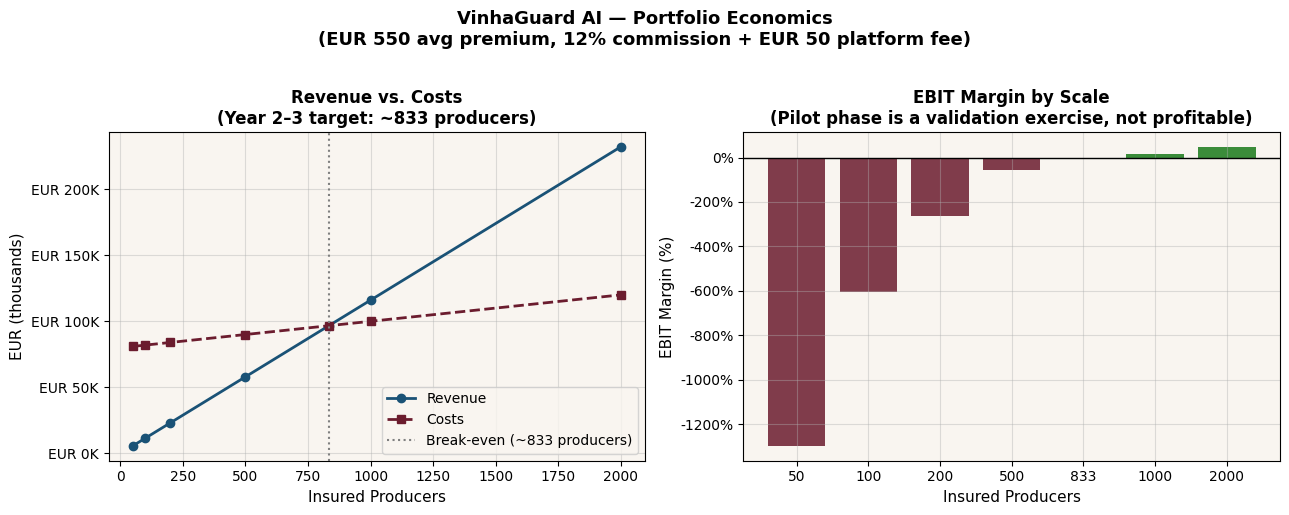

Chart saved: portfolio_economics.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(df_port['Producers'], df_port['Revenue']/1000, 'o-', color=BLUE, label='Revenue', lw=2)
ax1.plot(df_port['Producers'], df_port['Costs']/1000, 's--', color=BURGUNDY, label='Costs', lw=2)
ax1.axvline(x=breakeven_n, color='gray', linestyle=':', lw=1.5,
            label=f'Break-even (~{breakeven_n:.0f} producers)')
ax1.set_xlabel('Insured Producers', fontsize=11)
ax1.set_ylabel('EUR (thousands)', fontsize=11)
ax1.set_title('Revenue vs. Costs\n(Year 2–3 target: ~833 producers)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR {x:.0f}K'))

ax2 = axes[1]
margins_num = [float(m.replace('%','')) for m in df_port['EBIT Margin']]
bar_colors  = [BURGUNDY if m < 0 else '#1A7A1A' for m in margins_num]
ax2.bar([str(n) for n in producer_counts], margins_num, color=bar_colors, alpha=0.85)
ax2.axhline(y=0, color='black', lw=1)
ax2.set_xlabel('Insured Producers', fontsize=11)
ax2.set_ylabel('EBIT Margin (%)', fontsize=11)
ax2.set_title('EBIT Margin by Scale\n(Pilot phase is a validation exercise, not profitable)',
              fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('VinhaGuard AI — Portfolio Economics\n(EUR 550 avg premium, 12% commission + EUR 50 platform fee)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('portfolio_economics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: portfolio_economics.png')

## 5. Basis Risk Simulation

The prototype reports a dynamic **8–22% basis-risk indicator** (from `model/predict.py`).  
This is an **illustrative model diagnostic**, not a validated actuarial estimate.  
Actual basis risk depends on trigger design, ERA5 grid resolution (~9 km), and local micro-climate variability.

The simulation below shows what a representative basis-risk rate looks like across a producer cohort.

In [9]:
np.random.seed(42)
N = 500

# Use MVP trigger probability (8%), not the stress classification rate
trigger_fires = np.random.binomial(1, MVP_TRIGGER_PROB, N).astype(bool)

# Basis risk: trigger and actual loss are correlated but not identical
# If trigger fires → 80% chance of real loss (well-calibrated trigger)
# If no trigger   → prototype basis risk can still miss some real losses
PROTOTYPE_BASIS_RISK = 0.125
actual_loss = np.where(
    trigger_fires,
    np.random.binomial(1, 0.80, N).astype(bool),
    np.random.binomial(1, PROTOTYPE_BASIS_RISK, N).astype(bool),
)

tp = int(np.sum( trigger_fires &  actual_loss))
fp = int(np.sum( trigger_fires & ~actual_loss))
fn = int(np.sum(~trigger_fires &  actual_loss))  # missed losses — most damaging to trust
tn = int(np.sum(~trigger_fires & ~actual_loss))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f'=== Prototype Basis Risk Simulation (n={N}, MVP trigger prob {MVP_TRIGGER_PROB:.0%}) ===')
print(f'  True positives  (trigger fires, real loss):     {tp:3d} — correct payouts')
print(f'  False positives (trigger fires, no real loss):  {fp:3d} — overpayments')
print(f'  False negatives (no trigger, real loss):        {fn:3d} — MISSED LOSSES ⚠')
print(f'  True negatives  (no trigger, no real loss):     {tn:3d} — correct non-payouts')
print(f'')
print(f'  Precision: {precision:.1%} | Recall: {recall:.1%}')
print(f'')
print(f'  Prototype basis-risk indicator: {PROTOTYPE_BASIS_RISK:.1%}')
print(f'  ⚠ This is an illustrative model diagnostic, not a validated actuarial estimate.')
print(f'  Mitigation: per-location percentile triggers (already in make_dataset.py)')

=== Prototype Basis Risk Simulation (n=500, MVP trigger prob 8%) ===
  True positives  (trigger fires, real loss):      38 — correct payouts
  False positives (trigger fires, no real loss):    6 — overpayments
  False negatives (no trigger, real loss):         58 — MISSED LOSSES ⚠
  True negatives  (no trigger, no real loss):     398 — correct non-payouts

  Precision: 86.4% | Recall: 39.6%

  Prototype basis-risk indicator: 12.5%
  ⚠ This is an illustrative model diagnostic, not a validated actuarial estimate.
  Mitigation: per-location percentile triggers (already in make_dataset.py)


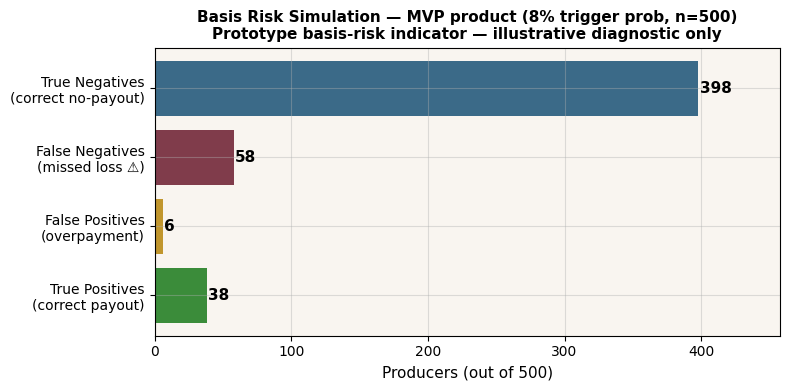

Chart saved: basis_risk.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
categories = [
    'True Positives\n(correct payout)',
    'False Positives\n(overpayment)',
    'False Negatives\n(missed loss ⚠)',
    'True Negatives\n(correct no-payout)'
]
values     = [tp, fp, fn, tn]
colors_br  = ['#1A7A1A', GOLD, BURGUNDY, BLUE]

bars = ax.barh(categories, values, color=colors_br, alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel(f'Producers (out of {N})', fontsize=11)
ax.set_title(
    f'Basis Risk Simulation — MVP product (8% trigger prob, n={N})\n'
    'Prototype basis-risk indicator — illustrative diagnostic only',
    fontsize=11, fontweight='bold')
ax.set_xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig('basis_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: basis_risk.png')

## 6. Business Case Summary

| Metric | Value | Status |
|---|---|---|
| Dataset size | 960 rows × 29 cols, 32 locations × 30 years | From `vinhaguard_dataset.parquet` |
| Positive class rate | 39.8% | Composite stress label |
| Climate stress probability (DS) | 72% | Risk dashboard use — not pricing input |
| Calibrated trigger prob (MVP) | ~8% | Pricing input — severe events only |
| MVP annual premium | EUR ~316–550 | EUR 5,000 fixed-payout policy |
| Break-even | ~833 producers | Year 2–3 target |
| Prototype basis-risk indicator | 8–22% | Illustrative — requires actuarial calibration |
| Payout target | <72 hours after trigger confirmation | Design target, not guaranteed |

**The business case holds when:**
1. The trained model replaces mock probabilities, enabling sub-location trigger calibration
2. The trigger is calibrated to severe events (~8–12%) rather than priced on the full stress rate
3. The insurer partner absorbs catastrophic correlated risk (e.g., 2022-style 100% stress across all Douro)
4. Basis risk is disclosed as a prototype indicator and reduced through finer trigger design
5. The cooperative pilot validates trust and willingness to pay before scaling

---
*VinhaGuard AI — Advanced Machine Learning Project, Nova SBE 2026*  
*Business and Insurance Analysis*